### Title: AgriSight: Cloud-Native Agricultural Commodity Price Analytics and Forecasting.

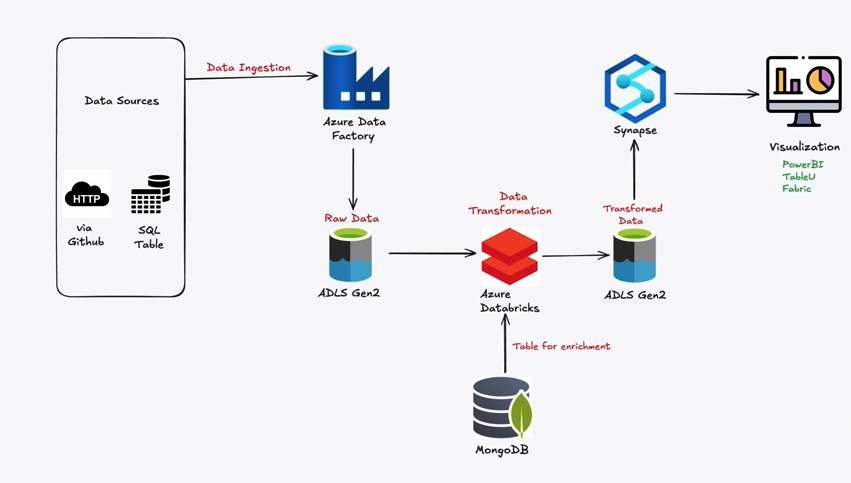

### Data Source:
https://www.kaggle.com/datasets/mikeeddie/us-agricultural-sales-dataset-2019-2023
https://www.kaggle.com/datasets/vijayveersingh/faostat-crops-and-livestock-data


In [ ]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 42.4 MB/s eta 0:00:00


In [ ]:
import mysql.connector
from mysql.connector import Error

hostname = "5lm-kn.h.filess.io"
database = "AgriSight_SQL_clothesif"
port = "61031"
username = "AgriSight_SQL_clothesif"
password = "adadf2d9d2600e53640b39d4fc5d21a3ca1da2fd"

connection = None
cursor = None

try:
    connection = mysql.connector.connect(
        host=hostname,
        database=database,
        user=username,
        password=password,
        port=port
    )
    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version", db_Info)
        cursor = connection.cursor()
        cursor.execute("SELECT DATABASE();")
        record = cursor.fetchone()
        print("You're connected to database:", record)
except Error as e:
    print("Error while connecting to MySQL", e)
finally:
    if cursor is not None:
        cursor.close()
    if connection is not None and connection.is_connected():
        connection.close()
        print("MySQL connection is closed")


/tmp/ipython-input-3548975386.py:22: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  db_Info = connection.get_server_info()


Connected to MySQL Server version 5.7.38-41
You're connected to database: ('AgriSight_SQL_clothesif',)
MySQL connection is closed


In [ ]:
import pandas as pd

In [ ]:
US_Sales = pd.read_csv('US_Products_database.csv')
US_Sales.head()
# US_Sales.shape

,Product ID,Product,Price ($)
0,100,Apples,1.36
1,101,Oranges,9.13
2,102,Blueberries,3.93
3,103,Strawberries,4.95
4,104,Peaches,2.77


In [ ]:
import pandas as pd
import mysql.connector
from mysql.connector import Error

hostname = "5lm-kn.h.filess.io"
database = "AgriSight_SQL_clothesif"
port = "61031"
username = "AgriSight_SQL_clothesif"
password = "adadf2d9d2600e53640b39d4fc5d21a3ca1da2fd"

csv_file_path = "US_Products_database.csv"
table_name = "US_Products_database"
connection = None
cursor = None

try:
    # 1) Connect
    connection = mysql.connector.connect(
        host=hostname,
        database=database,
        user=username,
        password=password,
        port=port
    )

    if connection.is_connected():
        print("Connected to MySQL Server successfully!")
        cursor = connection.cursor()

        # 2) Drop table if exists
        cursor.execute(f"DROP TABLE IF EXISTS {table_name};")
        print(f"Table `{table_name}` dropped if it existed.")

        # 3) Create table for Products
        create_table_query = f"""
        CREATE TABLE {table_name} (
            product_id INT PRIMARY KEY,
            product_name VARCHAR(100),
            price DECIMAL(10, 2)
        );
        """
        cursor.execute(create_table_query)
        print(f"Table `{table_name}` created successfully!")

        # 4) Load CSV
        data = pd.read_csv(csv_file_path)

        # Rename columns to match DB schema
        data = data.rename(columns={
            "Product ID": "product_id",
            "Product": "product_name",
            "Price ($)": "price"
        })

        print("CSV data loaded into pandas DataFrame.")

        # 5) Insert all rows (no need for batching here, but you can keep it)
        insert_query = f"""
        INSERT INTO {table_name} (
            product_id,
            product_name,
            price
        )
        VALUES (%s,%s,%s);
        """

        batch_records = [
            tuple(row)
            for row in data.itertuples(index=False, name=None)
        ]

        cursor.executemany(insert_query, batch_records)
        connection.commit()
        print(f"Inserted {len(batch_records)} product records successfully into `{table_name}`.")

except Error as e:
    print("Error while connecting to MySQL or inserting data:", e)

finally:
    if cursor is not None:
        cursor.close()
    if connection is not None and connection.is_connected():
        connection.close()
        print("MySQL connection is closed.")


Connected to MySQL Server successfully!
Table `US_Products_database` dropped if it existed.
Table `US_Products_database` created successfully!
CSV data loaded into pandas DataFrame.
Inserted 22 product records successfully into `US_Products_database`.
MySQL connection is closed.


In [ ]:
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 16.5 MB/s eta 0:00:00


In [ ]:

from pymongo import MongoClient
hostname = "xa5n44.h.filess.io"
database = "AgriSightNoSQL_doublecar"
port = "61034"
username = "AgriSightNoSQL_doublecar"
password = "b699eee488fd017a97c18bf9ae420fdb058ec24b"

uri = "mongodb://" + username + ":" + password + "@" + hostname + ":" + port + "/" + database

# Connect with the portnumber and host
client = MongoClient(uri)

# Access database
mydatabase = client[database]



# Task
I will load the data from the 'Production_Crops_Livestock_E_ItemCodes.csv' file into a pandas DataFrame, connect to MongoDB, prepare the data by converting DataFrame records into a list of dictionaries, create a new collection named 'Production_Crops_Livestock_E_ItemCodes' and upload the data, and finally, verify the data upload by retrieving a few documents from the new collection. Once completed, I will confirm the successful upload of the data to MongoDB.
```python
import pandas as pd
import pymongo
from pymongo import MongoClient

# Load the data from the CSV file
csv_file_path = 'Production_Crops_Livestock_E_ItemCodes.csv'
df = pd.read_csv(csv_file_path, encoding='latin1')

print("CSV data loaded into pandas DataFrame. First 5 rows:")
print(df.head())
print(f"DataFrame shape: {df.shape}")
```

## Load CSV Data

### Subtask:
Load the data from the 'Production_Crops_Livestock_E_ItemCodes.csv' file into a pandas DataFrame.


**Reasoning**:
Load the 'Production_Crops_Livestock_E_ItemCodes.csv' file into a pandas DataFrame, display its first 5 rows, and print its shape to understand its structure.



In [ ]:
df = pd.read_csv('Production_Crops_Livestock_E_ItemCodes.csv', encoding='latin1')
df.head()
df.shape

NameError: name 'pd' is not defined

**Reasoning**:
The previous code failed because the 'pandas' library was not imported. I need to import pandas as 'pd' to resolve the NameError and then execute the rest of the code to load the CSV, display its head, and print its shape.



In [ ]:
import pandas as pd
df = pd.read_csv('/content/Production_Crops_Livestock_E_ItemCodes.csv', encoding='latin1')
print("CSV data loaded into pandas DataFrame. First 5 rows:")
print(df.head())
print(f"DataFrame shape: {df.shape}")

CSV data loaded into pandas DataFrame. First 5 rows:
   Item Code CPC Code                                            Item
0        101   '01195                                     Canary seed
1       1016   '02123                                           Goats
2       1017   '21116                  Meat of goat; fresh or chilled
3       1018   '21156  Edible offal of goat; fresh; chilled or frozen
4       1019   '21515                            Goat fat; unrendered
DataFrame shape: (307, 3)


**Reasoning**:
The CSV data has been successfully loaded into a pandas DataFrame. The next step, as per the main task, is to prepare this data for MongoDB by converting the DataFrame records into a list of dictionaries.



In [ ]:
data_for_mongo = df.to_dict(orient='records')
print(f"Converted {len(data_for_mongo)} records to list of dictionaries for MongoDB upload. First 2 records:\n{data_for_mongo[:2]}")

Converted 307 records to list of dictionaries for MongoDB upload. First 2 records:
[{' Item Code': 101, ' CPC Code': "'01195", ' Item': 'Canary seed'}, {' Item Code': 1016, ' CPC Code': "'02123", ' Item': 'Goats'}]


**Reasoning**:
The data has been prepared in a list of dictionaries. Now, I will connect to MongoDB, create a new collection named 'Production_Crops_Livestock_E_ItemCodes', and insert the prepared data.



In [ ]:
from pymongo import MongoClient

# Connect to MongoDB using the URI
client = MongoClient(uri)
mydatabase = client[database]

# Define the collection name
collection_name = 'Production_Crops_Livestock_E_ItemCodes'
mycollection = mydatabase[collection_name]

# Insert the prepared data into the collection
result = mycollection.insert_many(data_for_mongo)

print(f"Data uploaded to collection '{collection_name}' successfully!")
print(f"Inserted {len(result.inserted_ids)} documents.")


Data uploaded to collection 'Production_Crops_Livestock_E_ItemCodes' successfully!
Inserted 307 documents.


**Reasoning**:
Now that the data has been uploaded to MongoDB, I will verify the successful upload by retrieving a few documents from the 'Production_Crops_Livestock_E_ItemCodes' collection.



In [ ]:
retrieved_documents = mycollection.find().limit(5)
print("Verifying data in MongoDB. First 5 documents:")
for doc in retrieved_documents:
    print(doc)

Verifying data in MongoDB. First 5 documents:
{'_id': ObjectId('693d500d0d380cb8d8852ff3'), ' Item Code': 101, ' CPC Code': "'01195", ' Item': 'Canary seed'}
{'_id': ObjectId('693d500d0d380cb8d8852ff4'), ' Item Code': 1016, ' CPC Code': "'02123", ' Item': 'Goats'}
{'_id': ObjectId('693d500d0d380cb8d8852ff5'), ' Item Code': 1017, ' CPC Code': "'21116", ' Item': 'Meat of goat; fresh or chilled'}
{'_id': ObjectId('693d500d0d380cb8d8852ff6'), ' Item Code': 1018, ' CPC Code': "'21156", ' Item': 'Edible offal of goat; fresh; chilled or frozen'}
{'_id': ObjectId('693d500d0d380cb8d8852ff7'), ' Item Code': 1019, ' CPC Code': "'21515", ' Item': 'Goat fat; unrendered'}


## Summary:

### Data Analysis Key Findings
*   A CSV file named `Production_Crops_Livestock_E_ItemCodes.csv` containing 307 records and 3 columns was successfully loaded into a pandas DataFrame.
*   The DataFrame was converted into a list of 307 dictionaries, preparing the data for MongoDB insertion.
*   All 307 records were successfully inserted into a new MongoDB collection named `Production_Crops_Livestock_E_ItemCodes`.
*   The data upload to MongoDB was verified by retrieving and displaying the first five documents from the newly populated collection.

### Insights or Next Steps
*   The established process provides a robust method for migrating structured CSV data into a NoSQL database like MongoDB, suitable for large datasets.
*   To optimize future data retrieval and ensure data integrity, consider implementing schema validation for the MongoDB collection and creating appropriate indexes on frequently queried fields.
